In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/college_student_placement_dataset.csv")
df.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [4]:
print("Размер таблицы:", df.shape)

Размер таблицы: (10000, 10)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  str    
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  str    
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  str    
dtypes: float64(2), int64(5), str(3)
memory usage: 894.3 KB


In [6]:
df.isnull().sum()

College_ID                0
IQ                        0
Prev_Sem_Result           0
CGPA                      0
Academic_Performance      0
Internship_Experience     0
Extra_Curricular_Score    0
Communication_Skills      0
Projects_Completed        0
Placement                 0
dtype: int64

In [7]:
df.describe()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,99.471800,7.535673,7.532379,5.546400,4.970900,5.561800,2.513400
std,15.053101,1.447519,1.470141,2.873477,3.160103,2.900866,1.715959
min,41.000000,5.000000,4.540000,1.000000,0.000000,1.000000,0.000000
25%,89.000000,6.290000,6.290000,3.000000,2.000000,3.000000,1.000000
50%,99.000000,7.560000,7.550000,6.000000,5.000000,6.000000,3.000000
75%,110.000000,8.790000,8.770000,8.000000,8.000000,8.000000,4.000000
max,158.000000,10.000000,10.460000,10.000000,10.000000,10.000000,5.000000


In [8]:
categorical_cols = [
    "College_ID",
    "Internship_Experience",
    "Placement"
]

numeric_cols = [
    "IQ",
    "Prev_Sem_Result",
    "CGPA",
    "Academic_Performance",
    "Extra_Curricular_Score",
    "Communication_Skills",
    "Projects_Completed"
]

print("Категориальные признаки:")
print(categorical_cols)

print("\nЧисловые признаки:")
print(numeric_cols)

Категориальные признаки:
['College_ID', 'Internship_Experience', 'Placement']

Числовые признаки:
['IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance', 'Extra_Curricular_Score', 'Communication_Skills', 'Projects_Completed']


In [9]:
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


College_ID:
College_ID
CLG0062    133
CLG0027    120
CLG0075    119
CLG0065    119
CLG0025    118
          ... 
CLG0006     83
CLG0035     83
CLG0060     83
CLG0054     79
CLG0042     75
Name: count, Length: 100, dtype: int64

Internship_Experience:
Internship_Experience
No     6036
Yes    3964
Name: count, dtype: int64

Placement:
Placement
No     8341
Yes    1659
Name: count, dtype: int64


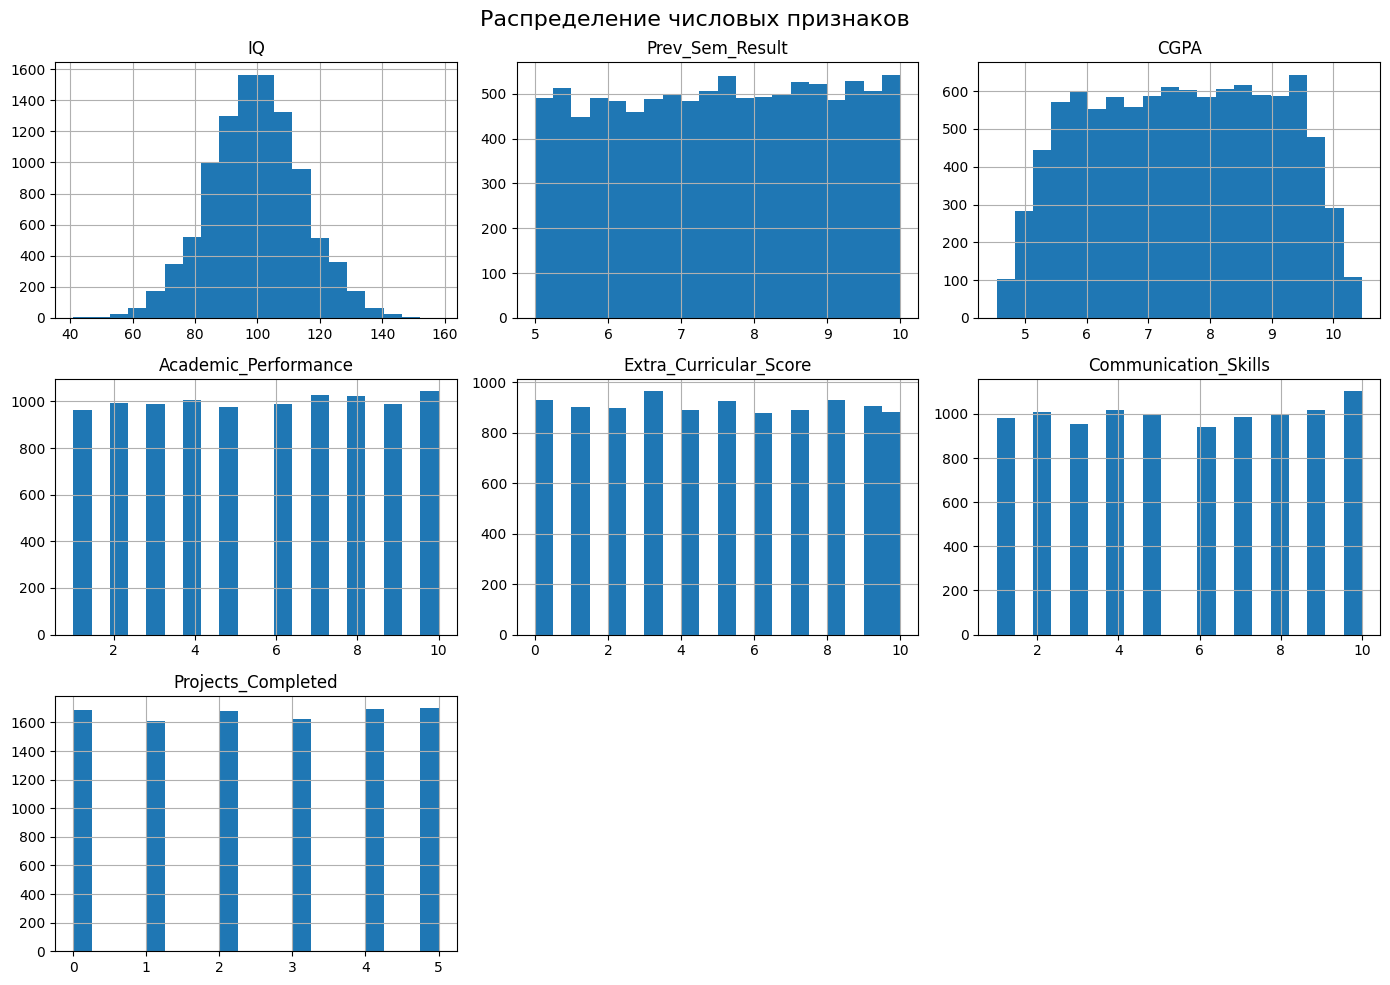

In [10]:
df[numeric_cols].hist(figsize=(14, 10), bins=20)

plt.suptitle("Распределение числовых признаков", fontsize=16)
plt.tight_layout()
plt.show()

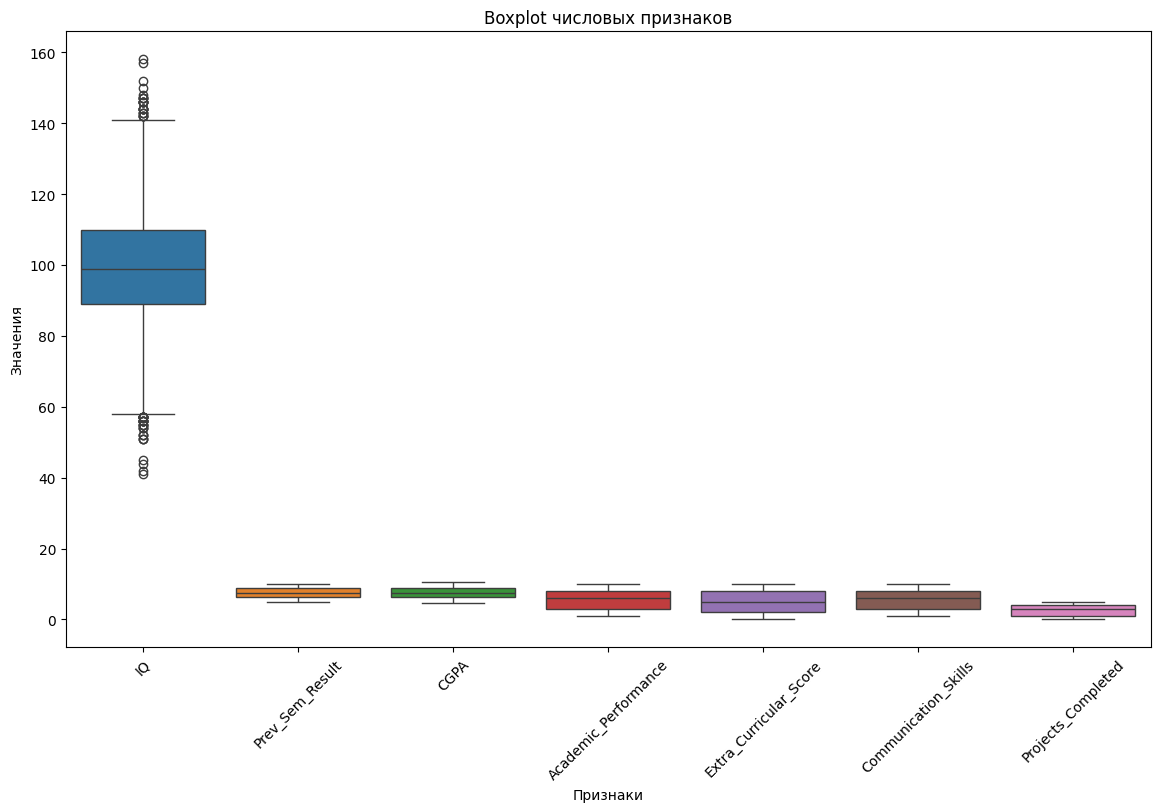

In [11]:
plt.figure(figsize=(14, 8))

sns.boxplot(data=df[numeric_cols])

plt.title("Boxplot числовых признаков")
plt.xlabel("Признаки")
plt.ylabel("Значения")
plt.xticks(rotation=45)
plt.show()

In [12]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} выбросов")

IQ: 61 выбросов
Prev_Sem_Result: 0 выбросов
CGPA: 0 выбросов
Academic_Performance: 0 выбросов
Extra_Curricular_Score: 0 выбросов
Communication_Skills: 0 выбросов
Projects_Completed: 0 выбросов


In [13]:
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


College_ID:
College_ID
CLG0062    133
CLG0027    120
CLG0075    119
CLG0065    119
CLG0025    118
          ... 
CLG0006     83
CLG0035     83
CLG0060     83
CLG0054     79
CLG0042     75
Name: count, Length: 100, dtype: int64

Internship_Experience:
Internship_Experience
No     6036
Yes    3964
Name: count, dtype: int64

Placement:
Placement
No     8341
Yes    1659
Name: count, dtype: int64


In [14]:
for col in categorical_cols:
    counts = df[col].value_counts()
    rare = counts[counts < 100]
    
    print(f"\n{col}:")
    print(f"Количество редких категорий (<100): {len(rare)}")
    print(rare)


College_ID:
Количество редких категорий (<100): 52
College_ID
CLG0096    99
CLG0043    99
CLG0085    98
CLG0033    98
CLG0022    98
CLG0087    97
CLG0100    97
CLG0081    97
CLG0031    97
CLG0003    97
CLG0044    96
CLG0021    96
CLG0009    96
CLG0015    95
CLG0017    95
CLG0040    95
CLG0082    95
CLG0016    95
CLG0083    95
CLG0068    94
CLG0008    94
CLG0074    94
CLG0011    94
CLG0059    94
CLG0007    94
CLG0036    93
CLG0064    93
CLG0089    93
CLG0018    92
CLG0079    92
CLG0004    91
CLG0057    91
CLG0053    91
CLG0050    90
CLG0093    90
CLG0019    90
CLG0052    90
CLG0099    89
CLG0063    88
CLG0028    88
CLG0055    86
CLG0024    86
CLG0076    86
CLG0037    86
CLG0002    86
CLG0070    85
CLG0048    85
CLG0006    83
CLG0035    83
CLG0060    83
CLG0054    79
CLG0042    75
Name: count, dtype: int64

Internship_Experience:
Количество редких категорий (<100): 0
Series([], Name: count, dtype: int64)

Placement:
Количество редких категорий (<100): 0
Series([], Name: count, dtype: in

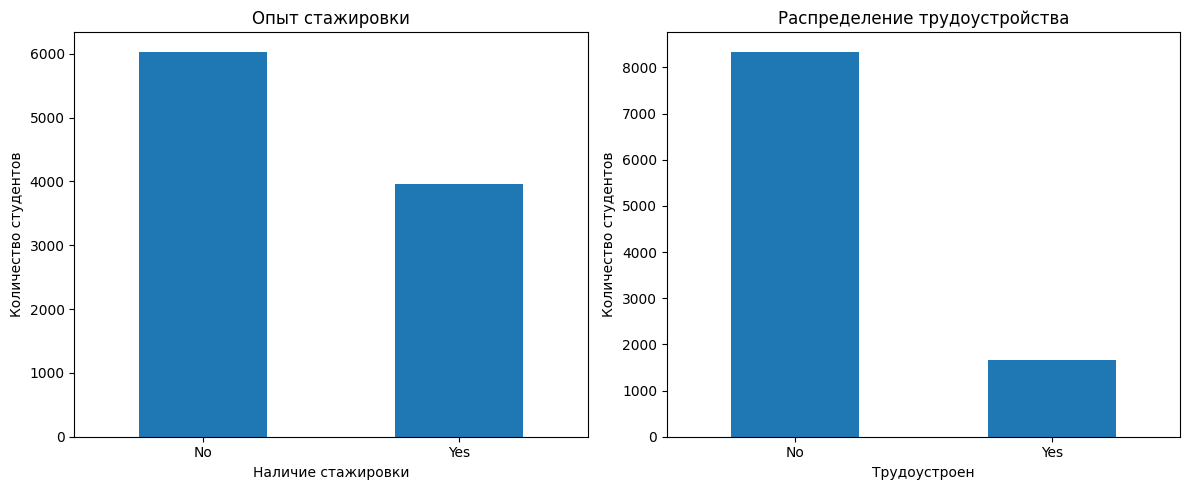

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df["Internship_Experience"].value_counts().plot(
    kind="bar", ax=axes[0]
)
axes[0].set_title("Опыт стажировки")
axes[0].set_xlabel("Наличие стажировки")
axes[0].set_ylabel("Количество студентов")
axes[0].tick_params(axis="x", rotation=0)

df["Placement"].value_counts().plot(
    kind="bar", ax=axes[1]
)
axes[1].set_title("Распределение трудоустройства")
axes[1].set_xlabel("Трудоустроен")
axes[1].set_ylabel("Количество студентов")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

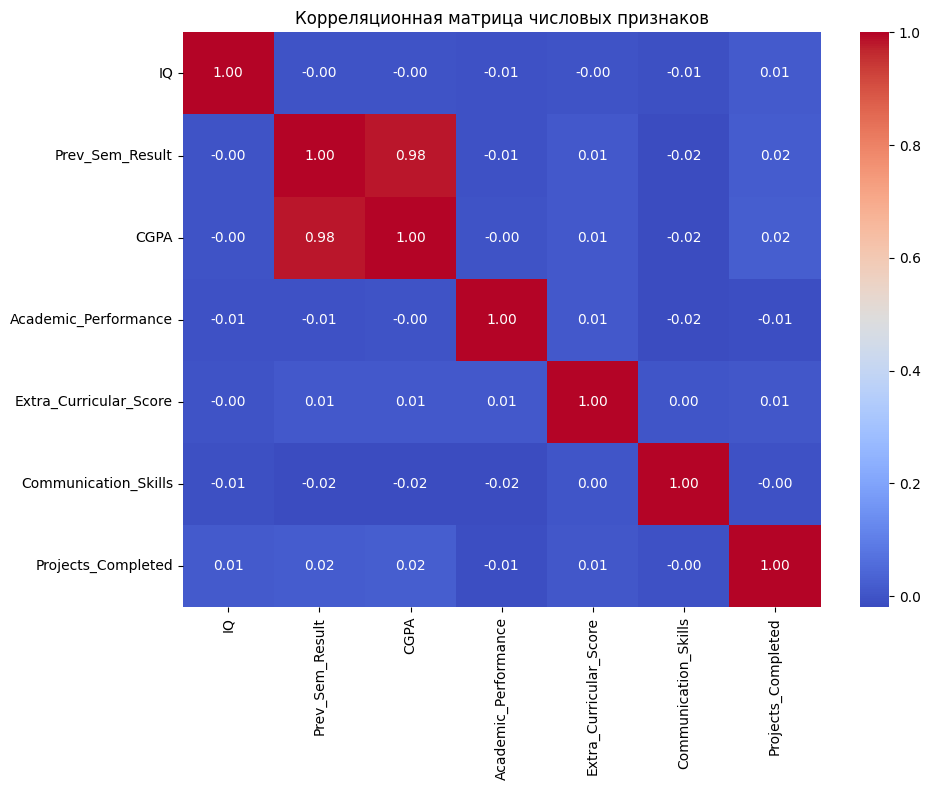

In [16]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Корреляционная матрица числовых признаков")
plt.tight_layout()
plt.show()

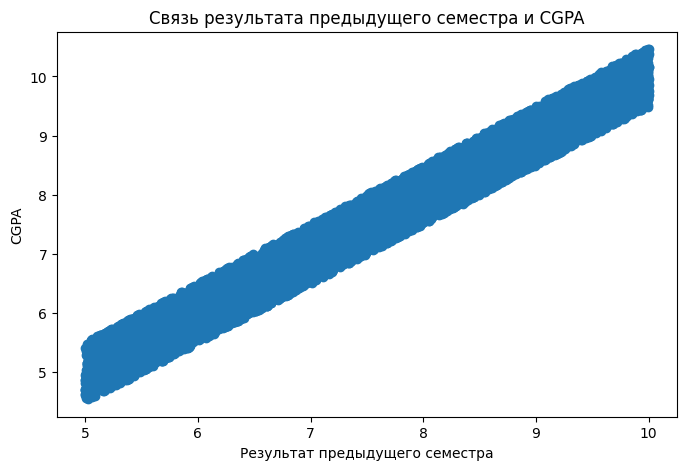

In [17]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Prev_Sem_Result"], df["CGPA"])

plt.title("Связь результата предыдущего семестра и CGPA")
plt.xlabel("Результат предыдущего семестра")
plt.ylabel("CGPA")

plt.show()

In [18]:
placement_counts = df["Placement"].value_counts()
placement_percent = df["Placement"].value_counts(normalize=True) * 100

print("Количество:")
print(placement_counts)

print("\nПроценты:")
print(placement_percent.round(2))

Количество:
Placement
No     8341
Yes    1659
Name: count, dtype: int64

Проценты:
Placement
No     83.41
Yes    16.59
Name: proportion, dtype: float64


## Выводы по визуализациям

### 1. Распределение числовых признаков
Гистограммы показывают распределение числовых признаков. Большинство признаков имеют достаточно равномерное распределение, однако у признака `IQ` наблюдаются значения, которые могут быть выбросами.

### 2. Выбросы
Boxplot показал потенциальные выбросы только у признака `IQ`. По критерию 1.5 × IQR было обнаружено 61 потенциальное выбросное значение. В остальных числовых признаках выбросы по этому критерию не обнаружены.

### 3. Категориальные признаки
Наиболее заметная особенность категориальных данных — неравномерное распределение целевой переменной `Placement`. Большинство студентов имеют значение `No`.

### 4. Корреляционная матрица
Самая сильная корреляция наблюдается между `Prev_Sem_Result` и `CGPA` и составляет 0.98. Между большинством остальных числовых признаков сильной линейной связи не наблюдается.

### 5. Диаграмма рассеяния
На scatter plot точки образуют плотную восходящую область, что подтверждает сильную положительную связь между `Prev_Sem_Result` и `CGPA`. Корреляция не означает причинно-следственную связь.

### 6. Целевая переменная
В `Placement` 83.41% студентов имеют значение `No`, а 16.59% — `Yes`. Это указывает на заметный дисбаланс классов.

## Итог: обнаруженные проблемы данных и дальнейшие действия

1. **Выбросы в `IQ`.** По критерию 1.5 × IQR обнаружено 61 потенциальное выбросное значение. На следующем этапе необходимо проверить эти значения и решить, являются ли они ошибками или реальными наблюдениями. Удалять их автоматически не следует.

2. **Очень высокая корреляция между `Prev_Sem_Result` и `CGPA`.** Коэффициент корреляции равен 0.98. Признаки содержат очень похожую информацию, поэтому перед построением модели стоит проверить их избыточность.

3. **Дисбаланс целевой переменной `Placement`.** 83.41% наблюдений относятся к `No` и только 16.59% — к `Yes`. При построении модели необходимо учитывать дисбаланс классов и выбрать подходящую метрику оценки.

4. **Высокая кардинальность `College_ID`.** В признаке присутствует 100 различных колледжей. Перед машинным обучением необходимо выбрать подходящий способ кодирования категориального признака.

5. **Категориальные признаки требуют подготовки.** `Internship_Experience`, `Placement` и `College_ID` являются категориальными признаками и перед использованием в большинстве моделей потребуют преобразования в числовой формат.

6. **Сильная связь между двумя признаками требует дополнительной проверки.** Корреляция 0.98 между `Prev_Sem_Result` и `CGPA` может указывать на избыточность признаков. На следующем занятии можно проверить, насколько оба признака необходимы модели.

7. **Пропущенные значения.** В ходе первичного анализа пропущенные значения не обнаружены, поэтому заполнение пропусков для данного датасета не требуется.